## Tutorial: running a variational quantum algorithm for an enzyme reaction

In this tutorial notebook, we will run a variational algorithm to estimate the energy of a molecule undergoing a bimolecular nucleophilic substitution ($S_N2$) reaction catalyzed by the Dehalogenase enzyme. These enzymes offer an extremely efficient and environmentally friendly method for degrading haloalkane compounds, which are potent pollutants, and could thus be useful for bioremediation tasks.

To start defining our problem, we import the relevant modules. All of the classes and methods we need will be found in the `qrunch` package. The documentation for the Kvantify Qrunch can be found [here](https://qrunch.docs.kvantify.net/index.html). We also define an output path to store the files we will generate along the way, and type in the setup logger, which allows us to keep track of basic information when running the algorithms.

In [1]:
from pathlib import Path
import qrunch as qc

output_path = Path("output")
output_path.mkdir(exist_ok=True, parents=True)

qc.setup_logger()

## Hardware requirements
The basic version of this tutorial, i.e. without the modifications suggested as exercises below, requires at least 16 GB of main memory and about 1 GB of disk space to run. Furthermore it is recommended to run this on a machine with at least 16 physical cores for the best user experience.

### Setting up the experiment

The starting point for our calculations is an .xyz file containing data for a model of the reaction catalyzed by the Dehalogenase enzyme. For simplicity, we have trimmed down the system to only the essential parts, so that this example can be run efficiently on a laptop. A more complete model (`dehalogenase_reaction_large.xyz`) can also be employed and should lead to a more realistic description (more on that further below).

The first step is to import the data. We generate a `Path` instance from it, which is an accepted input for our builders. 

In [15]:
reaction_path = Path("data/dehalogenase_reaction_small.xyz")

Now we will build our reaction configuration. In all frames of the reaction, we rely on [projective embedding theory](https://qrunch.docs.kvantify.net/docs/explanations/projective_embedding.html) to describe the system. This means the environment is handled through a DFT mean-field model, while the embedded atoms are treated explicitly with a high-level wave function method. In practice, this means we can directly provide the list of atoms forming the embedded region.

The first relevant input for building the reaction configuration is the basis set. In this example, we will choose the minimal basis (STO-3G) to keep things simple. We also know what is the total charge and spin of the system we are investigating, such that we can input those values. Here, the spin is defined as the difference between the number of alpha and beta electrons. 

Since we are interested in running projective embedding calculations, we can pass which atoms in the file will be present in the embedded region. We pass those as a list of integers (here, this corresponds to `[C, O, O, Cl, C]`).

In [16]:
reaction = qc.build_reaction_configuration(
    reaction=reaction_path,
    basis_set="sto3g",
    charge=-1,
    spin_difference=0,
    embedded_atoms=[5, 6, 7, 18, 19],
)

In the video below, you can see a movie displaying the reaction, where the embedded region is highlighted in light green.

<video width="320" height="240" controls>
  <source src="data/video.mp4" type="video/mp4">
</video>

### Creating the problem with the problem builder

We now come to the core of our problem definition, and where most of the relevant information is provided. 

Importing from our main module, we will use the [fluent build pattern](https://qrunch.docs.kvantify.net/docs/explanations/builder_pattern.html) to construct what a `problem_builder_creator`. This object defines what it is that we actually want to calculate for our molecular system, and how we wish to go about it. The philosophy for the usage of the `problem_builder_creator` is one of "narrowing down": we start big, with impactful choices such as picking between a reaction or a single molecular configuration, and then make more and more specific choices about how to handle these configurations.

For the case of this tutorial, the first thing we specify is that we want to calculate along a `reaction_path`, meaning that, when we later run the quantum algorithm for our problem, we will do so for all frames contained in the imported reaction file. Alternatively, if we had a single molecular configuration, we could simply specify that we want to calculate a `ground_state`. After choosing `reaction_path`, we specify the [even-handed](https://pubs.aip.org/aip/jcp/article/149/14/144101/196796/Even-handed-subsystem-selection-in-projection) approach, which ensures consistent partitioning for orbitals across the reaction.

In [17]:
reaction_builder_creator = qc.problem_builder_creator().reaction_path().even_handed()

In the next steps, we will follow a pattern that works whenever we are using a `creator` object. That is, we declare `choose` for a particular step and then specify which method we want to use.
The first choice is of `full_system_solver`: here we pick Density Functional Theory as our mean field method:

In [18]:
reaction_builder_creator = reaction_builder_creator.choose_full_system_solver().dft()

Next we choose an `embedded_orbital_calculator`, where we pick the Møller-Plesset second-order perturbation theory to generate natural molecular orbitals:

In [19]:
reaction_builder_creator = (
    reaction_builder_creator.choose_embedded_orbital_calculator().moller_plesset_2()
)

We then pick a `localizer`, where we use the Pipek-Mezey method to localize the occupied molecular orbitals: 

In [20]:
reaction_builder_creator = reaction_builder_creator.choose_localizer().pipek_mezey()

To assign molecular orbitals orbitals to the embedded region or the environment, we pick an `orbital_assigner` based on the total weights of their atomic orbital contributions, and pass a value to the `assignment tolerance` (here we know what is a valid choice based on prior mean-field calculations, but you can also rely on a default choice):

In [21]:
reaction_builder_creator = (
    reaction_builder_creator.choose_orbital_assigner().total_weight(
        assignment_tolerance=0.2
    )
)

And the last choice for the builder creator is the `projector_builder`, which separates the orbitals for the embedded region and environment. Here we go with the Manby level shift projector:

In [22]:
reaction_builder_creator = reaction_builder_creator.choose_projector_builder().manby()

We are almost ready to create the reaction builder. When considering which part of the system is crucial for our calculations, or what is the size of the quantum space we want to take into account, we have the option to define an active space, which is determined by a number of spatial orbitals and electrons. Any number of orbitals and electrons beyond this choice are considered frozen, and will have a fixed energy. 

The size of the active space will also define how many qubits our system will employ in the quantum algorithm. The active space specifications are added to our reaction builder as a `problem_modifier`. Here, we will consider 10 active spatial orbitals and 10 active electrons. 

Early on, we defined the spin difference as 0 which allows us to run a "restricted" calculation. This ensures that the number of alpha and beta electrons assigned to the embedded atoms is the same and the embedded space spin difference will also be 0. The number of beta electrons will be determined automatically by the embedded space spin difference and the specified number of alpha electrons. Thus we can construct the desired (10,10) active space by selecting the numbers as given in the following code cell.

In [23]:
reaction_builder_creator = reaction_builder_creator.add_problem_modifier().active_space(
    number_of_active_spatial_orbitals=10,
    number_of_active_alpha_electrons=5,
)

Note - in an embedded unrestricted calculation (and to some degree in an embedded restricted open shell calculation) the above rationale does not necessarily hold and the number of beta electrons may in general be different from the specified number of alpha electrons and one does not have explicit control over the number of electrons in the active space.

When running calculations on embedded systems, it is useful to store the mean field results and orbital assignment details so that this information can be reused every time we run energy calculations. For this we can choose a `data_persister_manager`. Below, we first generate a directory where the persister files will be saved, and then pass that as a path to the persister manager, along a customized extension and a `load_policy` (`"fallback"` means that, if the desired files are not already present in the folder, our program will generate them):

In [24]:
persister_path = output_path / "persister_data"
persister_path.mkdir(exist_ok=True, parents=True)

reaction_builder_creator = (
    reaction_builder_creator.choose_data_persister_manager().file_persister(
        directory=persister_path, extension=".qdk", load_policy="fallback"
    )
)

We are now ready to create the reaction builder:

In [25]:
reaction_builder = reaction_builder_creator.create()

And once the builder is set, we input our reaction, and build the even-handed reaction path problem. Here, we choose `build_restricted` since we have the same number of alpha and beta electrons.

This step is where all the embedding and orbital assignment calculations will be performed, and it can take up to several minutes to conclude that calculation on a laptop (it takes about 25 minutes running on a 12th Gen Intel(R) Core(TM) i7-1260P CPU). The good news is that this needs only to be done once, since the next time the files will be ready in the folder and we simply need to load them!

In [26]:
reaction_problem = reaction_builder.build_restricted(reaction)

### Running the quantum algorithm

For our purposes, most of the heavy lifting has been done in setting up the problem. Now, we can turn to defining which quantum algorithm to run and what specifications we desire for it. 

A good starting point is to define an `estimator` and a `sampler`. The distinction between these two objects is important as they share some of the same options. The `estimator` choice defines how quantities such as expectation values of observables will be calculated. This can be done, for instance, by keeping track of the evolution of the state vector through a classical simulation, or from measuring the state encoded in a quantum processing unit. The estimator will be used, for instance, for calculating the expectation values of the Hamiltonian, as required for variational optimization in a parametrized circuit.

The `sampler`, as the name suggests, return samples from the state. Again, here the state can be a classical simulation of the quantum state or a state encoded on quantum hardware. The main role of the sampler in the following is in performing gate selection.

In this example, we will rely on the `excitation_gate` choice for both the `estimator` and the `sampler`. This is Kvantify's proprietary simulator and it allows for very efficient simulation of state vectors with a fixed number of excitations, which is what we generally want in quantum chemistry. 

The estimator is then created as:

In [37]:
estimator = qc.estimator_creator().excitation_gate().create()

while the sampler follows the same pattern:

In [38]:
sampler = qc.sampler_creator().excitation_gate().create()

As mentioned above, the sampler will play a role in gate selection. Here we create our `gate_selector`, which will define how excitation gates will be ranked and selected at each adaptive step. A key choice here is what scheme for gate selection we will employ; for this tutorial, we will use the selection criteria from the [FAST-VQE algorithm](https://qrunch.docs.kvantify.net/docs/explanations/adaptive_vqe.html#fast-vqe-a-resource-efficient-adaptive-strategy).

We further define that we will not use shots for this purpose, so we rely on the full simulated state vector when performing gate selection.

In [39]:
gate_selector = (
    qc.gate_selector_creator().fast().with_sampler(sampler).with_shots(None).create()
)

With those elements, we can set up a VQE calculator using a `calculator_creator`.

In [40]:
calculator_creator = qc.calculator_creator()

Then, we specify that we want to calculate a VQE:

In [41]:
calculator_creator = calculator_creator.vqe()

This VQE should be iterative, or adaptive:

In [42]:
calculator_creator = calculator_creator.iterative()

And finally we choose `standard` to specify we do not aim to use a paired-electron approximation (for more on this, check out our [Butyronitrile dissociation](https://github.com/Kvantify/qrunch_tutorials/blob/main/butyronitrile-tutorial/butyronitrile_dissociation.ipynb) and [Covalent ligand](https://github.com/Kvantify/qrunch_tutorials/blob/main/covalent-ligand-tutorial/covalent-ligand-tutorial.ipynb) tutorials):

In [43]:
calculator_creator = calculator_creator.standard()

Next, we will specify our choice of `minimizer`. This object is responsible for using the energy estimates to optimize the gate parameters as we add them to the circuit. For our choice of minimizer we will go with `last_variable_fft()`, that relies on optimizing only the parameter of the latest added gate at each iteration using a Fast Fourier Transform (FFT)-based approach.

In [44]:
calculator_creator = calculator_creator.choose_minimizer().last_variable_fft()

To finish setting up the VQE calculator, we only need to pass the choices of `estimator` and `sampler` to the creator, and call `.create()`

In [45]:
fast_vqe_calculator = (
    calculator_creator.with_estimator(estimator)
    .with_gate_selector(gate_selector)
    .create()
)

Now, this is where all the chemistry definitions and the quantum algorithm come together. We will simply run the calculator by inputting our reaction problem. Notice that, since we are dealing with a reaction path, the calculator will perform the VQE, starting from the reference state and running until convergence or a maximum number of iterations is achieved (if you want to customize the number of iterations of the adaptive algorithm, check out the "Going big" section below). 

We call the output of this run `result` so that we can extract its details next. 

In [46]:
result = fast_vqe_calculator.calculate(reaction_problem)

2025-10-24 16:09:14 [ESSENTIAL] (kvantify.qrunch): Run Adaptive VQE algorithm with 20 qubits:
2025-10-24 16:09:14 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 1 / 10: -16.907877025349023
2025-10-24 16:09:14 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 2 / 10: -16.923463878731223
2025-10-24 16:09:14 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 3 / 10: -16.93092997452721
2025-10-24 16:09:14 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 4 / 10: -16.935581412775687
2025-10-24 16:09:14 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 5 / 10: -16.939884736977994
2025-10-24 16:09:14 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 6 / 10: -16.94436287151874
2025-10-24 16:09:15 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 7 / 10: -16.947586180986214
2025-10-24 16:09:15 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 8 / 10: -16.94941114295346
2025-10-24 16:09:15 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 9 / 10: -1

### Extracting results

With our calculations done, we can now have a look at the energies found across the reaction path, as well as how any particular point converges throughout the adaptive run. We will be using `numpy` and `matplotlib` for convenience here.

In [52]:
import numpy as np
import matplotlib.pyplot as plt

One thing we can do right away is look at the initial and final energies for all reaction frames. This provides a picture of the activation barrier for the reaction and also how much the quantum algorithm improved the energy overall. From our `results`, we can extract the initial and final energies for the reaction like so:

In [53]:
initial_reaction_energies = result.initial_total_energies.values
final_reaction_energies = result.total_energies.values

And then plot the arrays:

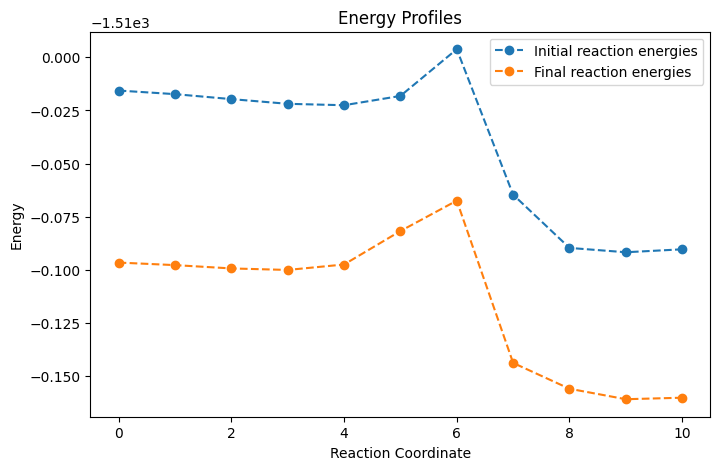

In [59]:
plt.figure(figsize=(8, 5))
plt.plot(
    initial_reaction_energies,
    marker="o",
    label="Initial reaction energies",
    linestyle="--",
)
plt.plot(
    final_reaction_energies,
    marker="o",
    label="Final reaction energies",
    linestyle="--",

)
plt.xlabel("Reaction Coordinate")
plt.ylabel("Energy")
plt.title("Energy Profiles")
plt.legend()
plt.show()

Here we see how well the system has converged to a lower energy over only a few iterations. We could also use this information to determine what is the energy of the activation barrier in this reaction. Have we actually found convergence for the energy on each of these points? Well, we can check that by looking at how the energies in a particular reaction frame evolve with the number of iterations. First, we single out a particular frame:

In [60]:
results_frame_6 = result.ground_state_problem_results[6]

and then we generate an array containing the `electronic_energy_per_macro_iteration` information:

In [63]:
energy_per_iteration_frame_6 = results_frame_6.electronic_energy_per_macro_iteration_with_initial_energy.values # type: ignore

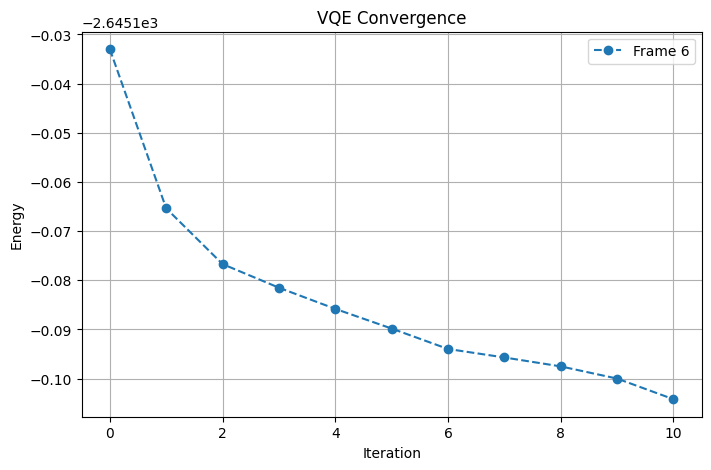

In [64]:
plt.figure(figsize=(8, 5))
plt.plot(
    energy_per_iteration_frame_6,
    label="Frame 6",
    linestyle="--",
    marker="o",
)
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("VQE Convergence")
plt.legend()
plt.grid()
plt.show()

Here we see how the energy on that particular frame has evolved. Each point in the plot corresponds to the addition of a parametrized gate and optimization of the corresponding parameter. Could we do better? How can I tell how good my approximation here is? You can address these questions and more yourself in the section below.

### Now it's your turn

In this section, you can have a go at running these algorithms by yourself. Suppose you wanted to be able to include more orbitals and electrons in your active space, to be considered in the quantum algorithm. This would effectively increase the number of qubits required, but potentially provide a more accurate description of the embedded region.

We could, for instance, specify

In [65]:
new_number_of_active_spatial_orbitals = 14
new_number_of_active_electrons = new_number_of_active_spatial_orbitals

while keeping the remaining definitions for the reaction problem identical. Here, we would like to generate a new `reaction_builder_creator` which is modified by the new active space. You can set it up by doing

In [66]:
new_reaction_builder_creator = (
    qc.problem_builder_creator()
    .reaction_path()
    .even_handed()
    .choose_full_system_solver()
    .dft()
    .choose_projector_builder()
    .manby()
    .choose_embedded_orbital_calculator()
    .moller_plesset_2()
    .choose_localizer()
    .pipek_mezey()
    .choose_orbital_assigner()
    .total_weight(assignment_tolerance=0.2)
    .choose_data_persister_manager()
    .file_persister(directory=persister_path, extension=".qdk", load_policy="fallback")
    # add your problem modifier here
    # ...
)

In this cell, we bunched all of the instructions for the reaction builder creator, for compactness. You can take it from here, run the quantum algorithm for this system and compare results between different active spaces. Also, instead of running a VQE, you could be interested in finding the a numerical solution through a configuration interaction approach. This could be done, for instance, by defining a different `calculator` based on a `configuration_interaction` approach. Notice that getting these solutions for large active spaces can be computationally challenging!

In [67]:
ci_calculator = qc.calculator_creator().configuration_interaction().standard().create()

### Going big

So far, all the calculations we ran in this tutorial were made under the assumption of a heavily simplified model for our enzyme-catalyzed reaction. But to get an accurate description of this process, we need to adopt a more complete approach. For instance, in this folder you can also find the file `dehalogenase_large_single_frame.xyz`; this file contains a single snapshot of a more complete description of the reaction, which includes a total of 85 atoms.

Let's start by importing the file for this molecular configuration:

In [68]:
molecular_configuration_path = Path("data/dehalogenase_large_single_frame.xyz")

In this larger system, the embedded atom indices are different. But again, since we know where we want to focus on, we can pass those numbers directly (the atomic elements are still the same). Furthermore, since we are aiming at running a more accurate simulation, we should rely on a bigger basis set to describe the orbitals. Here, we will choose `pc-seg-1`:

In [69]:
molecular_configuration = qc.build_molecular_configuration(
    molecule=molecular_configuration_path,
    basis_set="pc-seg-1",
    charge=-1,
    spin_difference=0,
    embedded_atoms=[5, 6, 7, 74, 75],
)

We now follow the same pattern as before for setting up our problem creator. A key difference here is that we will not rely on the `reaction_path` option, but rather on `ground_state` and then specify we want to handle a `projective_embedding` problem. For simplicity, we will chain most of the options in a single cell:

In [70]:
molecular_problem_builder_creator = (
    qc.problem_builder_creator()
    .ground_state()
    .projective_embedding()
    .choose_full_system_solver()
    .dft()
    .choose_embedded_orbital_calculator()
    .moller_plesset_2()
    .choose_orbital_assigner()
    .total_weight(assignment_tolerance=0.2)
    .choose_projector_builder()
    .manby()
    .choose_localizer()
    .pipek_mezey()
)

Since the embedded problem is different, we will need to generate new checkpoint files in our persister folder. To keep things tidy, we may want to generate a separate directory. So we create it and pass it as a choice for the `data_persister_manager`:

In [71]:
persister_path = Path("persister_data_large/")
persister_path.mkdir(exist_ok=True)

molecular_problem_builder_creator = (
    molecular_problem_builder_creator.choose_data_persister_manager().file_persister(
        directory=persister_path, extension=".qdk", load_policy="fallback"
    )
)

The last addition we want to make here is choose the size of the active space through the `problem_modifier`. Since the molecular configuration is larger now, it is reasonable to try and include more spatial orbitals and electrons in our problem. We will specify the number of spatial orbitals and electrons as:

In [72]:
number_of_active_spatial_orbitals = 20
number_of_active_electrons = number_of_active_spatial_orbitals

molecular_problem_builder_creator = (
    molecular_problem_builder_creator.add_problem_modifier().active_space(
        number_of_active_spatial_orbitals=number_of_active_spatial_orbitals,
        number_of_active_alpha_electrons=number_of_active_electrons // 2,
    )
)

This system will therefore include 40 spin orbitals and 20 electrons in total. With a [Pro License](https://qrunch.docs.kvantify.net/docs/getting_started.html#register-a-license) of Qrunch, you can increase the number of qubits used as much as the available classical and quantum computational power allows. We are now ready to create our builder:

In [73]:
molecular_problem_builder = molecular_problem_builder_creator.create()

and build the problem for our molecular configuration (NOTE: for safety, we comment out this step in the cell below. These embedding calculations will take much longer to run than the original example, and it is not advised to run this on a regular laptop. For instance, when performing these calculations for Kvantify's showcases, we employed an EC2 r6i.4xlarge – 16 vCPUs, 128 GB RAM virtual machine):

In [74]:
#molecular_problem = molecular_problem_builder.build_restricted(molecular_configuration)

Once we have set up the molecular problem, we can proceed as before with the quantum algorithm. We start by setting up the `estimator` and the `sampler`. Instead of using the `excitation_gate` simulator, we will now rely on using a `memory_restricted` approach, which allows for pruning the state vector simulation according to memory usage criteria. Those criteria can be specified, but here we pick `with_precise_defaults`. This configuration checks for the accuracy of the simulation, and keeps at a maximum 1,000,000 amplitudes in the state vector. The `memory_restricted` simulator is also included with the Qrunch Pro License.

In [75]:
estimator = qc.estimator_creator().memory_restricted().with_precise_defaults().create()
sampler = qc.sampler_creator().excitation_gate().create()

We then set up the `gate_selector` as before:

In [76]:
gate_selector = (
    qc.gate_selector_creator().fast().with_sampler(sampler).with_shots(None).create()
)

We can pass some customized choices for the `calculator_creator`. Specifically, we want to make sure we run for a fixed number of iterations in our adaptive algorithm. We do this by defining a maximum number of iterations and ensuring that it runs all the way through:

In [77]:
new_calculator_creator = (
    qc.calculator_creator()
    .vqe()
    .iterative()
    .standard()
    .with_options(
        qc.options.AdaptiveVqeOptions(max_iterations=50, force_all_iterations=True)
    )
)

Then we create our VQE and the calculator once more:

In [78]:
new_vqe_calculator = (
    calculator_creator.with_estimator(estimator).with_gate_selector(gate_selector).create()
)

And simply run it for our molecular problem. As before, the `result` object will contain information on the energies, convergence behaviour, etc.

In [79]:
#result = new_vqe_calculator.calculate(molecular_problem)